In [1]:
from alna import load_love_numbers_for_gins
from numpy import array
from gins_partials.tide_correction_model import REFERENCE_K2, IERS_LONG_PERIOD_ZONAL_TIDES

k2_reference = array(
    [
        REFERENCE_K2 + delta_k2_r + 1j * k2_i
        for _, _, delta_k2_r, k2_i in IERS_LONG_PERIOD_ZONAL_TIDES
    ]
)
tabs, love_number_log_frequencies, elastic, love_numbers, _ = load_love_numbers_for_gins(dummy_variable=9)

In [2]:
from gins_partials.tide_correction_model import (
    tide_angular_frequencies_to_cycle_per_yr,
    interpolate_love_number_grid_to_solid_tides,
)

interpolated_love_numbers = interpolate_love_number_grid_to_solid_tides(
    model_grid=love_numbers,
    love_number_log_frequencies=love_number_log_frequencies,
    solid_tide_frequencies=tide_angular_frequencies_to_cycle_per_yr(),
)

In [3]:
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import least_squares
from numpy import argsort
from numpy.random import uniform
from tqdm import tqdm

grids = tuple(tabs.values())
interpolators = [
    RegularGridInterpolator(
        grids,
        interpolated_love_numbers[..., i],
        bounds_error=False,
        fill_value=None,
    )
    for i in range(len(k2_reference))
]
lower_bounds = array([0.05, 200, -2, 2])
upper_bounds = array([0.4, 400, 1, 5])


def predict(p):
    p = array(p, dtype=float)
    return array([complex(interpolator(p)[0]) for interpolator in interpolators])


def residuals(p):
    return abs(predict(p) - array(k2_reference, dtype=complex))


results = []
costs = []

for i in tqdm(range(100)):

    result = least_squares(
        residuals,
        x0=array([uniform(low=low, high=high) for low, high in zip(lower_bounds, upper_bounds)]),
        bounds=(lower_bounds, upper_bounds),
    )
    results += [result.x]
    costs += [result.cost]

order = argsort(a=costs)
costs = array(costs)[order]
results = array(results)[order]

100%|██████████| 100/100 [03:16<00:00,  1.97s/it]


In [4]:
cost = costs[0]
x = results[0]
print(
    "Solution:\n" + "\n".join(f"{parameter} = {value}" for parameter, value in zip(tabs.keys(), x))
)
print("Relative error:", abs(cost) / REFERENCE_K2)

Solution:
\alpha^{MANTLE_0} = 0.09684612925519515
Q_\mu^{MANTLE_0} = 399.9414684833905
\log_{10}\Delta^{MANTLE_0} = -0.5000004300846198
\log_{10}\tau_{m-inf}^{MANTLE_0} = 4.009439187602673
Relative error: 1.224765285927038e-06


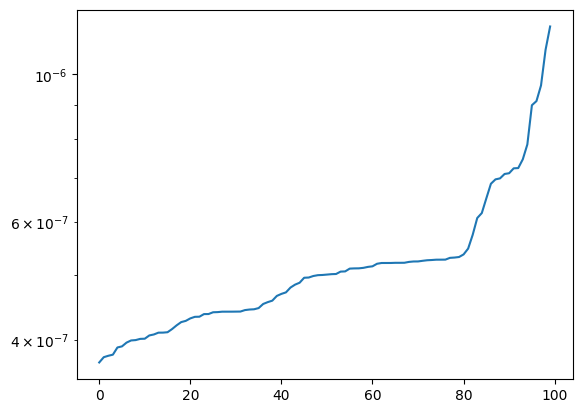

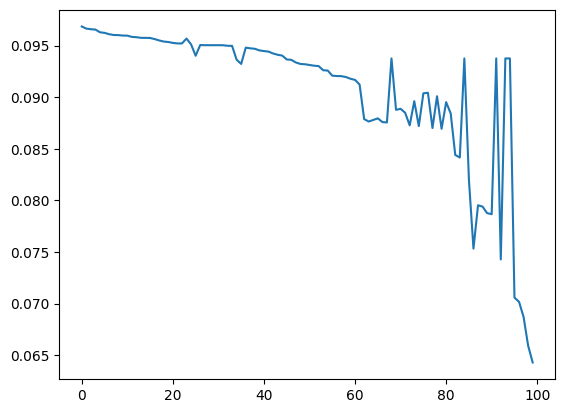

In [5]:
from matplotlib.pyplot import semilogy, plot, show

semilogy(costs)
show()
plot([result[0] for result in results])
show()

In [27]:
from alna.rheological_formulas import find_tau_m_sup

# TODO: Raise compatibility questions.
print(find_tau_m_sup(omega_m_inf=3.09e-5, period_unit=1, alpha=0.25, delta=10**1, q_mu=400) / 3600/24/365.25)

3.753126222170509


In [ ]:
from alna.rheological_formulas import find_tau_m_sup

print(find_tau_m_sup(omega_m_inf=1/10**x[3], period_unit=1, alpha=x[0], delta=10**x[2], q_mu=100) / 3600/24/365.25)
print(find_tau_m_sup(omega_m_inf=1/10**x[3], period_unit=1, alpha=x[0], delta=10**x[2], q_mu=200) / 3600/24/365.25)
print(find_tau_m_sup(omega_m_inf=1/10**x[3], period_unit=1, alpha=x[0], delta=10**x[2], q_mu=x[1]) / 3600/24/365.25)
print(find_tau_m_sup(omega_m_inf=1/10**x[3], period_unit=1, alpha=x[0], delta=10**x[2], q_mu=400) / 3600/24/365.25)

NameError: name 'x' is not defined

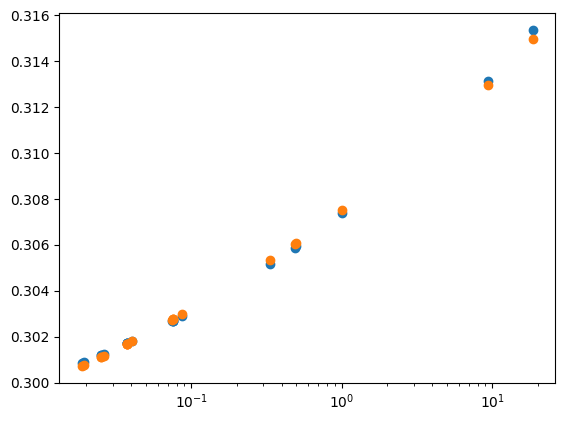

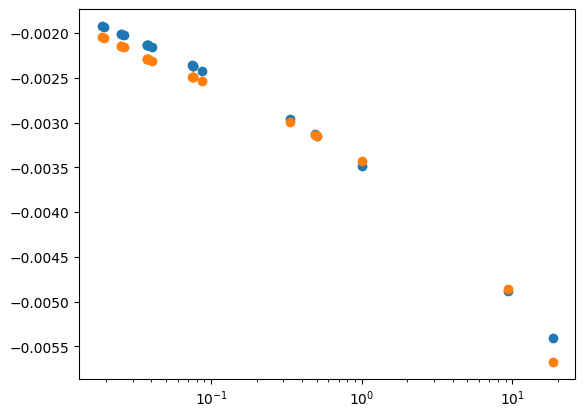

In [7]:
from matplotlib.pyplot import scatter, xscale, show
from numpy import log10

xscale("log")
scatter(1 / tide_angular_frequencies_to_cycle_per_yr(), k2_reference.real)
scatter(
    1 / tide_angular_frequencies_to_cycle_per_yr(),
    predict(x).real,
)
show()

xscale("log")
scatter(1 / tide_angular_frequencies_to_cycle_per_yr(), k2_reference.imag)
scatter(
    1 / tide_angular_frequencies_to_cycle_per_yr(),
    predict(x).imag,
)
show()